# **Intro**
This notebook serves as a continuation of my movie recommendation project, that I'm working on the summer of 2026. The previous notebook can be found at this link:

https://colab.research.google.com/drive/122Nx1q9xIRQCeUKvi98xsZrZ4rdLoV_B?authuser=3#scrollTo=6Qe6XudmUOvl

Summary of previous part:
- Built three movie recommendation models, each of which takes in a single movie and gives the top N recs.
  - First was a content-based recommender that used the following details to find similar films: genre, cast, writers, director, keywords, popularity, rating, runtime, and release year. It worked well for some movies that belonged clearly to a certain genre/niche, but overall wasn't the best.
  - Second was a collaborative filtering method that used the Surprise library and latent factor methods to create vectors for each movie. Recs were made by pulling the most similar vectors based on cosine similarity.
  - Third was a combined recommender that used both of the previous methods together. An initial large pool of movies was pulled based on the collaborative filtering method, with more specific recs being made by paring down the list based on content-based similarity.

I'm going to copy/paste some cells from the previous notebook as I plan on using this third recommender. It performed well enough in my testing to move forward with.


In this part of the project, I plan to make a system that can take in MORE THAN ONE movie as input, and give recs based on dat afrom all of them. I call this model the Movie Blender, and the main use-case is for when you can't decide between options for a movie night, instead of arguing with your friends and having to choose. I am using the TMDB dataset for content-based data.

**Ideas for blending**
- Make a soup of both movies combined and do content-based just for that.
- Run the model individually for both movies pulling a large amount of recs, and returning any movies that are in both lists (sorted by the highest average placement).
- Average their embedding vectors from latent-factor and find similar ones to that.

# Imports

In [ ]:
import requests
import time
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
import zipfile
import io
import matplotlib.pyplot as plt
from google.colab import userdata
!pip install surprise
from surprise import Dataset, SVD, Reader
from surprise.model_selection.search import GridSearchCV
from surprise.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import normalize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 104.7 MB/s eta 0:00:00


# Load/Format Data
I'll be using TMDB API and the MovieLens most up-to-date ratings dataset for this, which goes up to 2023. A big issue with my last movie recommender was that it didn't have newer movies, so I'm using the most current data I can. Going up to 2023 is missing a lot of good movies from the past few years, but it's the best I could find. The data for each movie that I'm taking is the features that I used in my content-based recommender in the previous part of this project; I'm going to recreate it here. Those features are:
- Cast
- Director
- Writers
- Keywords
- Production companies
- Genres
- Release year
- Rating
- Popularity
- Runtime

The ratings, links, and movies datasets will be used to make a collaborative filtering model to combine with the content-based one in the final recommender.

In [ ]:
import requests
import pandas as pd
import time

TMDB_API_KEY = userdata.get('TMDB_KEY')
BASE_URL = "https://api.themoviedb.org/3"
TARGET_MOVIES = 20_000

def fetch_discover_page(page, min_votes=100, year_gte=None, year_lte=None):
    params = {
        "api_key": TMDB_API_KEY,
        "sort_by": "vote_count.desc",
        "vote_count.gte": min_votes,
        "page": page
    }
    if year_gte:
        params["primary_release_date.gte"] = f"{year_gte}-01-01"
    if year_lte:
        params["primary_release_date.lte"] = f"{year_lte}-12-31"
    resp = requests.get(f"{BASE_URL}/discover/movie", params=params)
    return resp.json()

def fetch_year_range(year_gte, year_lte, min_votes=200, max_movies=None):
    """Fetch all movies (up to 10k) within a year range."""
    movies = []
    first_page = fetch_discover_page(1, min_votes, year_gte, year_lte)
    total_pages = min(first_page.get("total_pages", 1), 500)
    movies.extend(first_page.get("results", []))

    for page in range(2, total_pages + 1):
        if max_movies and len(movies) >= max_movies:
            break
        data = fetch_discover_page(page, min_votes, year_gte, year_lte)
        movies.extend(data.get("results", []))
        time.sleep(0.02)

    return movies

# Split into year ranges to avoid the 10k-per-query cap.
# Adjust ranges based on how movies are distributed (recent decades have more).
year_ranges = [
    (2020, 2026),
    (2010, 2019),
    (2000, 2009),
    (1990, 1999),
    (1900, 1989),
]

all_movies = []
for year_gte, year_lte in year_ranges:
    remaining = TARGET_MOVIES - len(all_movies)
    if remaining <= 0:
        break
    print(f"Fetching {year_gte}-{year_lte}...")
    chunk = fetch_year_range(year_gte, year_lte, min_votes=100, max_movies=remaining)
    all_movies.extend(chunk)
    print(f"  Got {len(chunk)} movies (total so far: {len(all_movies)})")

df = pd.DataFrame(all_movies)
df = df.drop_duplicates(subset="id").reset_index(drop=True)  # in case ranges overlap on edge dates
df = df.head(TARGET_MOVIES)
print(df.shape)

Fetching 2020-2026...
  Got 4019 movies (total so far: 4019)
Fetching 2010-2019...


ConnectionError: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))

In [ ]:

TMDB_API_KEY = userdata.get('TMDB_KEY')
BASE_URL = "https://api.themoviedb.org/3"

def extract_movie_fields(data):
    if not data:
        return None

    credits = data.get("credits", {})
    cast = credits.get("cast", [])
    crew = credits.get("crew", [])

    actors = [c["name"] for c in cast[:10]]  # top 10 billed
    directors = [c["name"] for c in crew if c.get("job") == "Director"]
    writers = [c["name"] for c in crew if c.get("job") in ("Writer", "Screenplay", "Story")]

    production_companies = [pc["name"] for pc in data.get("production_companies", [])]
    keywords = [k["name"] for k in data.get("keywords", {}).get("keywords", [])]
    genres = [g["name"] for g in data.get("genres", [])]

    release_date = data.get("release_date", "")
    release_year = release_date[:4] if release_date else None

    return {
        "id": data.get("id"),
        "title": data.get("title"),
        "actors": actors,
        "director": directors,
        "writers": writers,
        "production_companies": production_companies,
        "keywords": keywords,
        "genres": genres,
        "release_year": release_year,
        "popularity": data.get("popularity"),
        "runtime": data.get("runtime"),
        "rating": data.get("vote_average"),
        "vote_count": data.get("vote_count"),
    }

def fetch_movie(movie_id):
    try:
        resp = requests.get(
            f"{BASE_URL}/movie/{movie_id}",
            params={
                "api_key": TMDB_API_KEY,
                "append_to_response": "credits,keywords"
            },
            timeout=10
        )
        if resp.status_code == 200:
            return extract_movie_fields(resp.json())
    except requests.RequestException:
        return None
    return None

movie_ids = df['id'].tolist()
results = []
with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {executor.submit(fetch_movie, mid): mid for mid in movie_ids}
    for i, future in enumerate(as_completed(futures)):
        data = future.result()
        if data:
            results.append(data)
        if i % 500 == 0:
            print(f"Fetched {i}/{len(movie_ids)}")

movies_meta_df = pd.DataFrame(results)
print(movies_meta_df.shape)
movies_meta_df.head()

In [ ]:
# Sort by popularity
movies_meta_df = movies_meta_df.sort_values(by="popularity", ascending=False)
movies_meta_df.reset_index(drop=True, inplace=True)
movies_meta_df.head()

In [ ]:
url = "https://files.grouplens.org/datasets/movielens/ml-latest.zip"
resp = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(resp.content))
z.extractall("movielens_full")

ratings = pd.read_csv("movielens_full/ml-latest/ratings.csv")
movies = pd.read_csv("movielens_full/ml-latest/movies.csv")
links = pd.read_csv("movielens_full/ml-latest/links.csv")

print(ratings.shape, movies.shape)


In [ ]:
# Convert all ids in ratings to TMDB ids

tmdb_map = links.set_index('movieId')['tmdbId']

# map all at once — vectorized, no loop
ratings['movieId'] = ratings['movieId'].map(tmdb_map)

# drop unmapped rows and cast
ratings.dropna(subset=['movieId'], inplace=True)
ratings['movieId'] = ratings['movieId'].astype(int)

In [ ]:
ratings.head()

In [ ]:
def movie_title_from_id(id):
  # The 'id' column in movies_meta_df is integer type, so compare with int(id)
  movie_index = movies_meta_df.index[movies_meta_df['id'] == int(id)]
  if not movie_index.empty:
    movie_title = movies_meta_df.loc[movie_index, 'title'].iloc[0]
    return movie_title
  else:
    print(f"Movie ID {id} not found in movies_meta_df.")
    return f"MISSING: {id}"

def movie_id_from_title(title):
  movie_index = movies_meta_df.index[movies_meta_df['title'] == title]
  if not movie_index.empty:
    movie_id = movies_meta_df.loc[movie_index, 'id'].iloc[0]
    return movie_id
  else:
    return None

Other functions that pull directly from TMDB if can't find in database.

In [ ]:
import requests

TMDB_API_KEY = userdata.get('TMDB_KEY')
BASE_URL = "https://api.themoviedb.org/3"

def tmdb_title_from_id(movie_id):
    resp = requests.get(
        f"{BASE_URL}/movie/{movie_id}",
        params={"api_key": TMDB_API_KEY}
    )
    if resp.status_code != 200:
        print(f"No movie found with id: {movie_id}")
        return
    return resp.json()["title"]

def tmdb_id_from_title(title):
    resp = requests.get(
        f"{BASE_URL}/search/movie",
        params={"api_key": TMDB_API_KEY, "query": title}
    )
    results = resp.json().get("results", [])
    if not results:
        raise ValueError(f"No movie found with title: {title!r}")
    if len(results) > 1:
        print(f"Warning: multiple matches for {title!r}, returning the top result")
        for r in results[:5]:
            print(f"  - {r['title']} ({r.get('release_date', '?')[:4]}) id={r['id']}")
    return results[0]["id"]

In [ ]:
print(movie_id_from_title('Toy Story'))
print(movie_id_from_title('Defending Your Life'))

# **Build Latent Factor Model**
Some of the techniques I want to use for blending movie recs involve using a latent factor model, so I'll train one here to use later. I'm using the Surprise library for this. I trained/evaluated the same type of model in the previous notebook (linked again [here](https://colab.research.google.com/drive/122Nx1q9xIRQCeUKvi98xsZrZ4rdLoV_B?authuser=3#scrollTo=DlMQ-zvH_5Fi://)) so I won't document very much and will just provide the finished model.

In [ ]:
ratings.drop(columns=["timestamp"], inplace=True)
display(ratings['rating'].min())
display(ratings['rating'].max())
print(ratings.shape)

33 million ratings is computationally too expensive to train on, so I'm going to take a random sample of users and their ratings to pare down the dataset and speed up computation.

In [ ]:
TARGET_ROWS = 6_000_000

# Estimate the fraction of users needed to hit the target row count
total_rows = len(ratings)
frac_estimate = TARGET_ROWS / total_rows

unique_user_ids = ratings["userId"].unique()
sampled_user_ids = pd.Series(unique_user_ids).sample(frac=frac_estimate, random_state=0)

ratings_sample = ratings[ratings["userId"].isin(sampled_user_ids)]

print(f"Target rows: {TARGET_ROWS:,}")
print(f"Actual rows: {len(ratings_sample):,}")
print(f"Users included: {ratings_sample['userId'].nunique():,} / {ratings['userId'].nunique():,}")

In [ ]:
ratings_sample.head()

In [ ]:
reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(ratings_sample, reader)

Doing very limited hyperparam selection.

In [ ]:
params = {
    'n_factors': [35, 50, 75],
    'reg_all': [0.05, 0.1],
    'random_state': [0]
}

grid = GridSearchCV(SVD, param_grid=params, measures=['rmse', 'mae'], cv=2, n_jobs=2, joblib_verbose=3)
grid.fit(data)

In [ ]:
display(grid.best_score)
display(grid.best_params)

In [ ]:
# Trying with found params from last part of project
params = {
    'n_factors': [50],
    'n_epochs': [50],
    'lr_all': [0.005],
    'reg_all': [0.1],
    'random_state': [0]
}

grid = GridSearchCV(SVD, param_grid=params, measures=['rmse', 'mae'], cv=2, n_jobs=2, joblib_verbose=3)
grid.fit(data)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  2.1min finished


In [ ]:
display(grid.best_score)
display(grid.best_params)

{'rmse': np.float64(0.8443605635217919), 'mae': np.float64(0.6414068201984491)}

{'rmse': {'n_factors': 50,
  'n_epochs': 50,
  'lr_all': 0.005,
  'reg_all': 0.1,
  'random_state': 0},
 'mae': {'n_factors': 50,
  'n_epochs': 50,
  'lr_all': 0.005,
  'reg_all': 0.1,
  'random_state': 0}}

In [ ]:
model = SVD(n_factors=50, n_epochs=50, lr_all=0.005, reg_all=0.1, random_state=0)

trainset = data.build_full_trainset()
model.fit(trainset)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_movies_by_embedding(outer_movie_id, n=10):
  """
  Returns the top N outer movie IDs with the most similar embeddings
  to the given outer_movie_id.
  """
  try:
    # Convert outer movie ID to inner ID for the Surprise model
    inner_iid = trainset.to_inner_iid(outer_movie_id)
  except ValueError:
    print(f"Movie with outer ID {outer_movie_id} not found in the training data.")
    return [] # Return an empty list instead of a string

  # Get the embedding vector for the input movie
  input_embedding = model.qi[inner_iid]

  similarities = []
  # Iterate through all inner movie IDs in the trainset
  for other_inner_iid in trainset.all_items():
    if other_inner_iid == inner_iid:
      continue # Skip the movie itself

    other_embedding = model.qi[other_inner_iid]
    # Calculate cosine similarity between the two embeddings
    sim = cosine_similarity([input_embedding], [other_embedding])[0][0]

    # Convert other inner ID back to outer ID
    other_outer_id = trainset.to_raw_iid(other_inner_iid)
    similarities.append((sim, other_outer_id))

  # Sort by similarity in descending order
  similarities.sort(key=lambda x: x[0], reverse=True)

  # Return the top N outer movie IDs
  return [movie_id for sim, movie_id in similarities[:n]]

In [ ]:
similar_movies = get_similar_movies_by_embedding(int(movie_id_from_title('The Hudsucker Proxy')), n=10)
for movie_id in similar_movies:
    print(f"- {movie_title_from_id(movie_id)} (ID: {movie_id})")

- Trainspotting (ID: 627)
- The Royal Tenenbaums (ID: 9428)
- A Clockwork Orange (ID: 185)
- In Bruges (ID: 8321)
- The Proposition (ID: 16608)
- Miller's Crossing (ID: 379)
- Adaptation. (ID: 2757)
- Twelve Monkeys (ID: 63)
- Life of Brian (ID: 583)
- Apocalypse Now (ID: 28)


The latent factor model is done, essentially all copied from the last notebook. Now we can try the first Movie Blender strategy!!

# **Method 1: Average Embedding**
This first method for the movie blender will use the latent factor embeddings we just made in the last section. The idea here is to average the values of the embeddings to create a new embedding vector, and generate predictions based on that.

In [ ]:
def avg_embedding_rec(movie_ids, n=10):
  "Returns a list of n movie recs given a list of movie ids"
  embeddings = []
  input_inner_iids = set()

  for movie_id in movie_ids:
    inner_iid = trainset.to_inner_iid(movie_id)
    embeddings.append(model.qi[inner_iid])
    input_inner_iids.add(inner_iid)

  avg_embedding = np.mean(embeddings, axis=0)

  similarities = []
  # Iterate through all inner movie IDs in the trainset
  for other_inner_iid in trainset.all_items():
    if other_inner_iid in input_inner_iids:
      continue # Skip all input movies, not just the last one

    other_embedding = model.qi[other_inner_iid]
    # Calculate cosine similarity between the two embeddings
    sim = cosine_similarity([avg_embedding], [other_embedding])[0][0]

    # Convert other inner ID back to outer ID
    other_outer_id = trainset.to_raw_iid(other_inner_iid)
    similarities.append((sim, other_outer_id))

  # Sort by similarity in descending order
  similarities.sort(key=lambda x: x[0], reverse=True)

  # Return the top N outer movie IDs
  return [movie_id for sim, movie_id in similarities[:n]]

In [ ]:
movie_ids = [tmdb_id_from_title('Airplane!'),
             tmdb_id_from_title('Raising Arizona')]
recs = avg_embedding_rec(movie_ids, n=10)
for movie_id in recs:
    print(f"- {tmdb_title_from_id(movie_id)} (ID: {movie_id})")

  - Airplane! (1980) id=813
  - Airplane Mode (2020) id=652483
  - Airplane Mode (2019) id=550115
  - Airplane II: The Sequel (1982) id=2665
  - Airplane 2025 (2025) id=1498014
- This Is Spinal Tap (ID: 11031)
- Blazing Saddles (ID: 11072)
- Monty Python and the Holy Grail (ID: 762)
- The Last Detail (ID: 14886)
- The Wild Bunch (ID: 576)
- Get Shorty (ID: 8012)
- Young Frankenstein (ID: 3034)
- Gimme Shelter (ID: 132)
- Bananas (ID: 11302)
- The Killer (ID: 10835)


In [ ]:
movie_ids = [tmdb_id_from_title('Interstellar'),
             tmdb_id_from_title('Gravity')]
recs = avg_embedding_rec(movie_ids, n=10)
for movie_id in recs:
    print(f"- {tmdb_title_from_id(movie_id)} (ID: {movie_id})")

In [ ]:
movie_ids = [tmdb_id_from_title('Knives Out'),
             tmdb_id_from_title('Murder on the Orient Express')]
recs = avg_embedding_rec(movie_ids, n=10)
for movie_id in recs:
    print(f"- {tmdb_title_from_id(movie_id)} (ID: {movie_id})")

  - Knives Out (2019) id=546554
  - Glass Onion: A Knives Out Mystery (2022) id=661374
  - Wake Up Dead Man: A Knives Out Mystery (2025) id=812583
  - Knives Out (2016) id=481638
  - Knives Out (2024) id=1369985
  - Murder on the Orient Express (2017) id=392044
  - Murder on the Orient Express (1974) id=4176
  - Murder on the Orient Express (2015) id=468556
  - Murder on the Orient Express (2001) id=6110
  - Making 'Murder on the Orient-Express' (2004) id=627337
- Dumbo (ID: 329996)
- Jeff, Who Lives at Home (ID: 82532)
- Eye in the Sky (ID: 333352)
- Going in Style (ID: 353070)
- Battle of the Sexes (ID: 369192)
- Magic in the Moonlight (ID: 229297)
- The Many Saints of Newark (ID: 524369)
- The Post (ID: 446354)
- A Man Called Otto (ID: 937278)
- The Adam Project (ID: 696806)


In [ ]:
movie_ids = [tmdb_id_from_title('Wedding Crashers'),
             tmdb_id_from_title('Saving Private Ryan')]
recs = avg_embedding_rec(movie_ids, n=10)
for movie_id in recs:
    print(f"- {tmdb_title_from_id(movie_id)} (ID: {movie_id})")

  - Wedding Crashers (2005) id=9522
  - Undercover Wedding Crashers (2021) id=613098
  - Saving Private Ryan (1998) id=857
  - Into the Breach: Saving Private Ryan (1999) id=1531825
- There's Something About Mary (ID: 544)
- The Hangover (ID: 18785)
- Meet the Parents (ID: 1597)
- American Pie (ID: 2105)
- Beverly Hills Cop (ID: 90)
- Trading Places (ID: 1621)
- National Lampoon's Vacation (ID: 11153)
- Braveheart (ID: 197)
- Lethal Weapon (ID: 941)
- The Simpsons Movie (ID: 35)


In [ ]:
movie_ids = [tmdb_id_from_title('Fight Club'),
             tmdb_id_from_title('A Few Good Men')]
recs = avg_embedding_rec(movie_ids, n=10)
for movie_id in recs:
    print(f"- {tmdb_title_from_id(movie_id)} (ID: {movie_id})")

  - Fight Club (1999) id=550
  - Zombie Fight Club (2014) id=289732
  - Fight Club (2023) id=1213076
  - Fight Club: RENESANCE () id=1585271
  - Jurassic Fight Club (2008) id=151912
  - A Few Good Men (1992) id=881
  - A Few Good Men From The North (2025) id=1494835
  - Let The Truth Be Told: Chronicles of a Few Good Men (2019) id=1422319
  - Florence, Arizona (2015) id=403585
- Collateral (ID: 1538)
- The Matrix (ID: 603)
- The Untouchables (ID: 117)
- 3:10 to Yuma (ID: 5176)
- Braveheart (ID: 197)
- Looper (ID: 59967)
- The Prestige (ID: 1124)
- Gangs of New York (ID: 3131)
- The Town (ID: 23168)
- Inception (ID: 27205)


**Conclusion** \
This method seems to works fairly well actually, getting movies that seem to be movies that would be liked based on the input films, but one glaring issue is that the recs just aren't that similar to the inputs (Murder on the Orient Express + Knives Out should recommend some murder mysteries). This makes a lot of sense as the ouputs are based only on the model that was trained to predict ratings. The latent factors that are used to get recs here aren't based on any actual info about the movie, so movies with similar latent factors are not guarenteed to actually be similar. In addition, movies with wildly different latent factor vectors are going to avergae out somewhere in between, which is great in theory, but in practice means that some of the recs are going to be very different from one or both of the inputs (as seen in the last blend between wedding crashers and Saving Private Ryan; the comedy recs are nothing at all like saving private ryan).   

# Method 1.2: Weighted Averages
I also wanted to see if you can weight the recs in one direction or another, by weighting the values of each side according to an input. Below is a function that does this.

In [ ]:
def weighted_avg_embedding_rec(movies_weights, n=10):
  "Returns a list of n movie recs given a list of movie ids"
  "movies_weights should be an array of tuples, where each has a movie id and a weight associated."
  "Weights should be between 0-1 and add up to 1."
  embeddings = []
  input_inner_iids = set()
  movie_ids = [movie_id for movie_id, _ in movies_weights]
  weights = [weight for _, weight in movies_weights]

  for movie_id in movie_ids:
    inner_iid = trainset.to_inner_iid(movie_id)
    embeddings.append(model.qi[inner_iid])
    input_inner_iids.add(inner_iid)

  avg_embedding = np.average(embeddings, axis=0, weights=weights)

  similarities = []
  # Iterate through all inner movie IDs in the trainset
  for other_inner_iid in trainset.all_items():
    if other_inner_iid in input_inner_iids:
      continue # Skip all input movies, not just the last one

    other_embedding = model.qi[other_inner_iid]
    # Calculate cosine similarity between the two embeddings
    sim = cosine_similarity([avg_embedding], [other_embedding])[0][0]

    # Convert other inner ID back to outer ID
    other_outer_id = trainset.to_raw_iid(other_inner_iid)
    similarities.append((sim, other_outer_id))

  # Sort by similarity in descending order
  similarities.sort(key=lambda x: x[0], reverse=True)

  # Return the top N outer movie IDs
  return [movie_id for sim, movie_id in similarities[:n]]

In [ ]:
movie_ids = [(tmdb_id_from_title('Finding Nemo'), 0.6),
             (tmdb_id_from_title('The Grand Budapest Hotel'), 0.4)]
recs = weighted_avg_embedding_rec(movie_ids, n=10)
for movie_id in recs:
    print(f"- {tmdb_title_from_id(movie_id)} (ID: {movie_id})")

  - Finding Nemo (2003) id=12
  - Children's Aquarium: Finding the Real Nemo & Dory (2015) id=648081
  - Finding Dory (2016) id=127380
- WALL·E (ID: 10681)
- The Princess Bride (ID: 2493)
- Up (ID: 14160)
- How the Grinch Stole Christmas! (ID: 13377)
- For the Birds (ID: 13930)
- A Christmas Story (ID: 850)
- Toy Story 3 (ID: 10193)
- Arsenic and Old Lace (ID: 212)
- Ratatouille (ID: 2062)
- Toy Story (ID: 862)


In [ ]:
movie_ids = [(tmdb_id_from_title('Finding Nemo'), 0.4),
             (tmdb_id_from_title('The Grand Budapest Hotel'), 0.6)]
recs = weighted_avg_embedding_rec(movie_ids, n=10)
for movie_id in recs:
    print(f"- {tmdb_title_from_id(movie_id)} (ID: {movie_id})")

  - Finding Nemo (2003) id=12
  - Children's Aquarium: Finding the Real Nemo & Dory (2015) id=648081
  - Finding Dory (2016) id=127380
- Rear Window (ID: 567)
- Butch Cassidy and the Sundance Kid (ID: 642)
- The Gold Rush (ID: 962)
- Lifeboat (ID: 13321)
- Spartacus (ID: 967)
- The Iron Giant (ID: 10386)
- La La Land (ID: 313369)
- Amadeus (ID: 279)
- A Close Shave (ID: 532)
- Europa Europa (ID: 8996)


Very cool! You can do weighted averages. You can see how even a 10% shift in one direction or another can change what you get out.

# **Method 2: Combined Soup**
In this section I'm going to make recs based on the following data from the movies' metadata:
- Cast
- Director
- Writers
- Keywords
- Production companies
- Genres
- Rating
- Popularity
- Runtime

It's essentially going to be the content-based recommender from my first notebook, but using combined metadata instead of just metadata from one movie.

In [ ]:
display(movies_meta_df.head())

First we have to fix all the strings so that they're counted as one token in the soup; concatenate all so that each name is one word, and make everything lower case. This way, Robert Downey Jr. and Robert Redford for example won't be counted the same (both Robert).

In [ ]:
def fix_names(x):
  for i in range(len(x)):
    x[i] = x[i].lower()
    x[i] = x[i].replace(" ", "")
  return x

movies_meta_df['actors'] = movies_meta_df['actors'].apply(fix_names)
movies_meta_df['director'] = movies_meta_df['director'].apply(fix_names)
movies_meta_df['writers'] = movies_meta_df['writers'].apply(fix_names)
movies_meta_df['production_companies'] = movies_meta_df['production_companies'].apply(fix_names)
movies_meta_df['keywords'] = movies_meta_df['keywords'].apply(fix_names)

In [ ]:
display(movies_meta_df.head())

Now write a function to create the soup of text that the vectorizer will use.

In [ ]:
def soupify(x):
  'Returns a string based on a row from the movie metadata df'
  soup = ""

  for i in range(len(x['actors'])):
    soup += x['actors'][i] + " "
    # Only take the top 5 actors
    if i == 5:
      break

  for i in range(len(x['director'])):
    # Add each director 3 times
    soup += x['director'][i] + " "
    soup += x['director'][i] + " "
    soup += x['director'][i] + " "

  for i in range(len(x['writers'])):
    soup += x['writers'][i] + " "

  for i in range(len(x['production_companies'])):
    soup += x['production_companies'][i] + " "

  for i in range(len(x['keywords'])):
    soup += x['keywords'][i] + " "


  for i in range(len(x['genres'])):
    # Include the genre twice
    soup += x['genres'][i] + " "
    soup += x['genres'][i] + " "

  return soup

In [ ]:
movies_meta_df['soup'] = movies_meta_df.apply(soupify, axis=1)

In [ ]:
print(movies_meta_df['soup'][0])

mattdamon tomholland annehathaway robertpattinson himeshpatel johnleguizamo christophernolan christophernolan christophernolan christophernolan universalpictures syncopy ship trojanwar greekmythology historicalfiction ancientworld perioddrama basedonsong,poemorrhyme greekhistory voyage peplum ancient trojanhorse mediterraneansea bronzeage mythical odyssey swordandsandal epicfantasy Adventure Adventure Action Action Fantasy Fantasy 


Create a count vectorizer to use later

In [ ]:
cv = CountVectorizer(stop_words='english', token_pattern=r"(?u)\S+")

Write a function that makes a new combined soup, excludes the input movies, and fits the vectorizer based on the changed dataset.

In [ ]:
def combined_vectorizer(movies):
  new_soup = ""
  for movie_title in movies:
    try:
      movie_id = tmdb_id_from_title(movie_title)
    except ValueError as e:
      print(f"Warning: {e}. Skipping movie '{movie_title}'.")
      continue

    # Check if the movie_id exists in movies_meta_df
    movie_row = movies_meta_df[movies_meta_df['id'] == movie_id]
    if not movie_row.empty:
      new_soup += " " + movie_row['soup'].iloc[0]
    else:
      print(f"Warning: Movie ID {movie_id} (title: '{movie_title}') not found in movies_meta_df (likely due to filtering or fetch limits). Skipping.")

  # Fit cv on all real soups and the combined soup of the input movies
  count_matrix = cv.fit_transform(pd.concat([movies_meta_df['soup'], pd.Series([new_soup])], ignore_index=True))
  return count_matrix

Now find cosine similarity between the last row (new soup) and all other rows.

In [ ]:
def combined_soup_rec(movies, n=10):
  matrix = combined_vectorizer(movies)
  sim_scores = cosine_similarity(matrix[-1], matrix[:-1]).flatten()
  movie_indices = sim_scores.argsort()[-n - len(movies): -len(movies)][::-1]
  return movies_meta_df['title'].iloc[movie_indices].tolist()

In [ ]:
input_movies = ['Baby Driver', 'Interstellar']

print(combined_soup_rec(input_movies))

  - Baby Driver (2017) id=339403
  - Baby Driver Cartoon - Bellbottoms () id=910587
  - Interstellar (2014) id=157336
  - Inside 'Interstellar' (2015) id=529107
  - Lolita from Interstellar Space (2014) id=287954
  - Interstellar: Nolan's Odyssey (2014) id=301959
  - Interstellar Wandering (2019) id=649745
['Inception', 'The Dark Knight Rises', "The World's End", 'Batman Begins', 'Tenet', 'The Dark Knight', 'The Running Man', 'The Prestige', 'The Odyssey', 'Hot Fuzz']


Ok, interesting start, but I can already see a major issue with this recommender. If a single movie exists that is very similar to one of the movies, it is going to dominate the recs since it has such a strong match with one of the soups. Instead of recommending movies similar to both, it is kind of just combining the two rec lists for each individual movie.

We still have a step to do though, which is to include the numerical cols (popularity, rating, runtime). First scale everything with MinMaxScaler.

In [ ]:
movies_meta_df['vote_count'] = np.log1p(movies_meta_df['vote_count'])

In [ ]:
scaler = MinMaxScaler()
num_cols = ['vote_count', 'rating', 'runtime']
movies_meta_df[num_cols] = scaler.fit_transform(movies_meta_df[num_cols])

In [ ]:
display(movies_meta_df[num_cols].head())

,vote_count,rating,runtime
0,0.414727,0.764502,0.295726
1,0.053300,0.504214,0.196581
2,0.444421,0.662494,0.249573
3,0.498740,0.650967,0.189744
4,0.594887,0.789291,0.186325


Now write a function to sort a list of movies based on their numeric similarity to average of the main ones

In [ ]:
from scipy.spatial import distance
def numeric_cols(id):
  num_df = movies_meta_df[movies_meta_df['id'] == id][['vote_count', 'rating', 'runtime']]
  return num_df

def numeric_similarity(movies, similar_movies):
  num_cols_list = []
  for movie in movies:
    movie_index = movie_id_from_title(movie)
    movie_num_cols = numeric_cols(movie_index)
    num_cols_list.append(movie_num_cols)

  movie_num_cols = pd.concat(num_cols_list).mean()

  for i in range(len(similar_movies)):
    comparison_index = movie_id_from_title(similar_movies[i])
    comparison_num_cols = numeric_cols(comparison_index).values.flatten()
    dist = euclidean_distances([movie_num_cols], [comparison_num_cols])
    similar_movies[i] = (similar_movies[i], dist)

  return similar_movies

In [ ]:
input_movies = ['Baby Driver', 'Interstellar']

similar_movies = combined_soup_rec(input_movies)
similar_movies = numeric_similarity(input_movies, similar_movies)
print(similar_movies)

  - Baby Driver (2017) id=339403
  - Baby Driver Cartoon - Bellbottoms () id=910587
  - Interstellar (2014) id=157336
  - Inside 'Interstellar' (2015) id=529107
  - Lolita from Interstellar Space (2014) id=287954
  - Interstellar: Nolan's Odyssey (2014) id=301959
  - Interstellar Wandering (2019) id=649745
[('Inception', array([[0.08661108]])), ('The Dark Knight Rises', array([[0.04708016]])), ("The World's End", array([[0.29057827]])), ('Batman Begins', array([[0.03988356]])), ('Tenet', array([[0.171966]])), ('The Dark Knight', array([[0.09085046]])), ('The Running Man', array([[0.47507096]])), ('The Prestige', array([[0.07397498]])), ('The Odyssey', array([[0.51578381]])), ('Hot Fuzz', array([[0.19822343]]))]


In [ ]:
def sort_movies(movies):
  "Sorts movies by numeric similarity"
  sorted_movies = sorted(movies, key=lambda x: x[1])
  return sorted_movies

def n_most_similar(movies, n, k):
  top_k = combined_soup_rec(movies, k)
  top_k = numeric_similarity(movies, top_k)
  top_k = sort_movies(top_k)
  return [movie[0] for movie in top_k[:n]]

In [ ]:
input_movies = ['Finding Nemo', 'Burn After Reading']
display(n_most_similar(input_movies, n=10, k=50))

  - Finding Nemo (2003) id=12
  - Children's Aquarium: Finding the Real Nemo & Dory (2015) id=648081
  - Finding Dory (2016) id=127380


['Toy Story 4',
 "A Bug's Life",
 'Finding Dory',
 'Fargo',
 'Inside Out 2',
 'The Big Lebowski',
 'No Country for Old Men',
 'True Grit',
 'The Secret Life of Pets',
 'O Brother, Where Art Thou?']

In [ ]:
input_movies = ['Napoleon Dynamite', 'Obsession']
display(n_most_similar(input_movies, n=10, k=50))

  - Napoleon Dynamite (2004) id=8193
  - On Location Napoleon Dynamite (2006) id=1084657
  - World Premiere - Jared Hess: A Non-Linear Look at the Director of Napoleon Dynamite (2006) id=1287072
  - Obsession (2026) id=1339713
  - Obsession (1976) id=4780
  - Obsession (2015) id=332672
  - Private Obsession (1995) id=158576
  - My Teacher, My Obsession (2018) id=530442


['Send Help',
 'Insidious: Chapter 2',
 'Nacho Libre',
 'Insidious: The Last Key',
 'A Minecraft Movie',
 'Black Phone 2',
 'Prey',
 'Insidious',
 'Phenomena',
 'Housebound']

This is a pretty terrible result. Instead of coming up with a combined rec list, it's kind of just smooshing the two different recommendation lists together. The numeric step didn't really help. This method is not viable for a combined recommender system.

# **Method 2.2: Average content-based vectors**
This isn't working well. Instead of combining the soup and vecotrizing based on that, I'm going to try vectorizing individually and averaging the vectors, just like in method 1.

In [ ]:
cv_2 = CountVectorizer(stop_words='english', token_pattern=r"(?u)\S+")
count_matrix = cv_2.fit_transform(movies_meta_df['soup'])

In [ ]:
def avg_sim_recs(movie_ids, n=10):
  movie_idxs = []
  # Get indices of movies with movie ids
  for id in movie_ids:
    idx = movies_meta_df.index[movies_meta_df['id'] == id][0]
    movie_idxs.append(idx)

  # Get the vectors for the input movies and average them
  input_vectors = count_matrix[movie_idxs]
  avg_vector = np.asarray(input_vectors.mean(axis=0))

  # Compute cosine similarity between the average vector and every movie in count_matrix
  sim_scores = cosine_similarity(avg_vector, count_matrix)[0]

  # Pair each similarity score with its index
  sim_scores_with_idx = list(enumerate(sim_scores))

  # Exclude the input movies themselves
  sim_scores_with_idx = [(i, score) for i, score in sim_scores_with_idx if i not in movie_idxs]

  # Sort by similarity, descending
  sim_scores_with_idx.sort(key=lambda x: x[1], reverse=True)

  # Take top n
  top_idxs = [i for i, score in sim_scores_with_idx[:n]]

  # Return titles
  return movies_meta_df.loc[top_idxs, 'title'].tolist()

In [ ]:
movie_ids = [tmdb_id_from_title("The Lego Movie"), tmdb_id_from_title("Interstellar")]
recs = avg_sim_recs(movie_ids, n=10)
for movie in recs:
    print(movie)

  - The Lego Movie (2014) id=137106
  - The Lego Batman Movie (2017) id=324849
  - The Lego Ninjago Movie (2017) id=274862
  - The Lego Movie 2: The Second Part (2019) id=280217
  - LEGO® Atlantis: The Movie (2010) id=76324
  - Interstellar (2014) id=157336
  - Inside 'Interstellar' (2015) id=529107
  - Lolita from Interstellar Space (2014) id=287954
  - Interstellar: Nolan's Odyssey (2014) id=301959
  - Interstellar Wandering (2019) id=649745
The Lego Movie 2: The Second Part
Cloudy with a Chance of Meatballs
Project Hail Mary
Inception
Cosmic Scrat-tastrophe
DC League of Super-Pets
Planet 51
Doraemon the Movie: Nobita's Little Star Wars 2021
Doraemon: New Nobita's Great Demon - Peko and the Exploration Party of Five
Doraemon: Nobita's Treasure Island


In [ ]:
input_movies = ['The Lego Movie', 'Interstellar']

print(combined_soup_rec(input_movies))

  - The Lego Movie (2014) id=137106
  - The Lego Batman Movie (2017) id=324849
  - The Lego Ninjago Movie (2017) id=274862
  - The Lego Movie 2: The Second Part (2019) id=280217
  - LEGO® Atlantis: The Movie (2010) id=76324
  - Interstellar (2014) id=157336
  - Inside 'Interstellar' (2015) id=529107
  - Lolita from Interstellar Space (2014) id=287954
  - Interstellar: Nolan's Odyssey (2014) id=301959
  - Interstellar Wandering (2019) id=649745
['The Lego Movie 2: The Second Part', 'Cloudy with a Chance of Meatballs', 'Project Hail Mary', 'Inception', 'Cosmic Scrat-tastrophe', 'DC League of Super-Pets', "Doraemon: New Nobita's Great Demon - Peko and the Exploration Party of Five", 'Planet 51', "Doraemon the Movie: Nobita's Little Star Wars 2021", "Doraemon: Nobita's Treasure Island"]


Before even trying the numeric step, I can already see that this is outputing the same movies just in a slightly different order, so I'm not going to pursue this further.

# **Method 3: Hybrid Recommender**
The embedding vectors form method 1 do a good job of recommending movies with a similar vibe, but not movies that are actually very similar, unlike method 2. Maybe adding features like genre and keywords to the end of the latent factor embedding vectors will help push things in the right direction. First, make an upddated soupify function that only includes things that influence the tone of a movie (genre, keywords, writers, director). Heavy emphasis on genre.

In [ ]:
def soupify_2(x):
  'Returns a string based on a row from the movie metadata df'
  soup = ""


  for i in range(len(x['director'])):
    # Add each director 2 times
    soup += x['director'][i] + " "
    soup += x['director'][i] + " "

  for i in range(len(x['keywords'])):
    soup += x['keywords'][i] + " "
    soup += x['keywords'][i] + " "

  for i in range(len(x['writers'])):
    soup += x['writers'][i] + " "

  for i in range(len(x['genres'])):
    # Include the genre 7 times
    soup += x['genres'][i] + " "
    soup += x['genres'][i] + " "
    soup += x['genres'][i] + " "
    soup += x['genres'][i] + " "
    soup += x['genres'][i] + " "
    soup += x['genres'][i] + " "
    soup += x['genres'][i] + " "

  return soup

In [ ]:
movies_meta_df['soup2'] = movies_meta_df.apply(soupify_2, axis=1)

In [ ]:
print(movies_meta_df['soup2'][0])

In [ ]:
from scipy.sparse import vstack, csr_matrix

# Vectorize soup2 (rows correspond to movies_meta_df's own row order)
count_vectorizer2 = CountVectorizer(min_df=3, stop_words='english', token_pattern=r"(?u)\S+")
soup2_matrix = count_vectorizer2.fit_transform(movies_meta_df['soup2'])  # sparse, n_meta_movies x vocab_size

# Map TMDB id -> row index in movies_meta_df
id_to_row = {tmdb_id: row_idx for row_idx, tmdb_id in enumerate(movies_meta_df['id'])}

n_items = trainset.n_items

# Walk the trainset once, keeping only movies that have soup2 metadata.
# Nothing is allocated for the ~34k uncovered movies at all.
filtered_inner_iids = []
filtered_raw_ids = []
soup2_rows = []

for inner_iid in range(n_items):
    raw_id = trainset.to_raw_iid(inner_iid)
    row_idx = id_to_row.get(raw_id)
    if row_idx is not None:
        filtered_inner_iids.append(inner_iid)
        filtered_raw_ids.append(raw_id)
        soup2_rows.append(soup2_matrix[row_idx])

n_covered = len(filtered_raw_ids)
print(f"Keeping {n_covered} / {n_items} movies that have soup2 metadata")

soup2_filtered = vstack(soup2_rows).tocsr()   # sparse (n_covered, vocab_size)
qi_filtered = model.qi[filtered_inner_iids]   # dense but small (n_covered, n_factors)

The trainset movies that have no soup2 metadata (were too unpopular to get picked up during original scan from TMDB) are mostly inconsequential and can be dropped.

Also going to include the vote count and average rating of each movie on the vector as well, since, too often the model was recommending "bad" movies for "good" inputs, which is not ideal. I also feel like people who input popular movies don't want to watch some unknown film, hence including popularity.

In [ ]:
# vote_count and rating are already log-transformed / MinMax-scaled to [0, 1]
# in movies_meta_df, so just pull them directly — no re-transforming needed.
row_indices = [id_to_row[raw_id] for raw_id in filtered_raw_ids]
pop_rating_arr = movies_meta_df.loc[row_indices, ['vote_count', 'rating']].values
pop_rating_arr = np.nan_to_num(pop_rating_arr, nan=0.0)

print(pop_rating_arr.shape)  # (n_covered, 2)
print(pop_rating_arr[:5])    # sanity check — should be small floats in [0, 1]

Popularity and rating are weighted less, since they have little to do with the actual vibe of the film.

In [ ]:
from scipy.sparse import hstack

qi_norm = normalize(qi_filtered, axis=1)
soup2_norm = normalize(soup2_filtered, axis=1)
pop_rating_norm = normalize(pop_rating_arr, axis=1)

CONTENT_WEIGHT = 1.0       # soup2 (genre/tone/director) strength
POP_RATING_WEIGHT = .5    # popularity + critical acclaim strength

combined_matrix_filtered = hstack([
    csr_matrix(qi_norm),
    CONTENT_WEIGHT * soup2_norm,
    csr_matrix(POP_RATING_WEIGHT * pop_rating_norm),
]).tocsr()

print(combined_matrix_filtered.shape)  # (n_factors + vocab_size + 2)

In [ ]:
def weighted_avg_embedding_rec(movies_weights, n=10):
  "Returns a list of n movie recs given a list of movie ids"
  "movies_weights should be an array of tuples, where each has a movie id and a weight associated."
  "Weights should be between 0-1 and add up to 1."
  embeddings = []
  input_idxs = set()
  weights = []
  skipped = []

  for movie_id, weight in movies_weights:
    if movie_id not in raw_to_filtered_idx:
      skipped.append(movie_id)
      continue
    idx = raw_to_filtered_idx[movie_id]
    embeddings.append(combined_matrix_filtered[idx].toarray().ravel())  # densify just this one row
    input_idxs.add(idx)
    weights.append(weight)

  if skipped:
    print(f"Skipped (no soup2 metadata, so excluded from the model entirely): {skipped}")

  if not embeddings:
    raise ValueError("None of the input movies have soup2 metadata.")

  avg_embedding = np.average(embeddings, axis=0, weights=weights).reshape(1, -1)

  sims = cosine_similarity(avg_embedding, combined_matrix_filtered)[0]

  ranked = sorted(
      ((sim, idx) for idx, sim in enumerate(sims) if idx not in input_idxs),
      key=lambda x: x[0],
      reverse=True
  )[:n]

  return [filtered_idx_to_raw[idx] for sim, idx in ranked]

raw_to_filtered_idx = {raw_id: idx for idx, raw_id in enumerate(filtered_raw_ids)}
filtered_idx_to_raw = {idx: raw_id for idx, raw_id in enumerate(filtered_raw_ids)}

In [ ]:
input_movies = [(tmdb_id_from_title("Knives Out"), 1)]

recs = weighted_avg_embedding_rec(input_movies, n=10)
for movie in recs:
    print(tmdb_title_from_id(movie))

WHOA! This is really good, it's recommending actual murder mysteries for a murder mystery input. More tests!

In [ ]:
input_movies = [(tmdb_id_from_title("The Big Lebowski"), 0.5),
                (tmdb_id_from_title("The Grand Budapest Hotel"), 0.5)]

recs = weighted_avg_embedding_rec(input_movies, n=20)
for movie in recs:
    print(tmdb_title_from_id(movie))

Amazing, a combo of wes anderson and coen brothers that have a good blend to them. Also fun to see Hudsucker Proxy on here as one of the Coen's least popular movies (BUT a good match, since it's a silly comedy just like Grand Budapest!)

In [ ]:
input_movies = [(tmdb_id_from_title("Inside Llewyn Davis"), 0.33),
                (tmdb_id_from_title("Ted"), 0.33),
                (tmdb_id_from_title("Napoleon Dynamite"), 0.33)]

recs = weighted_avg_embedding_rec(input_movies, n=10)
for movie in recs:
    print(tmdb_title_from_id(movie))

These are all amazing results. This is the model I want to use for the final product.

**CONCLUSION:** \
This is definitely the best result so far, which makes sense; hybrid recommenders often are the best of both worlds. In my previous notebook, I created a hybrid recommender at the end and it had by far the best results. Overall, the method of finding movies near the average of the input vectors is the same as in method 1, we just changed what the input vectors look like here. Vectors are now:
- Embeddings from latent factor model (Weighted 1x)
- Countvectorized soup of movie metadata (Weighted 1x)
- Scaled data of popularity and average rating (weighted 0.5x)

Overall, this method's balance of semantic and content similarity is why I am using these vectors for the final recs on the website.

# **BONUS: KNN Mapping**

NOTE: All the code in this section was generated by AI and I didn't use this at all in the Movie Blender website, I include it here because it's fun to look at.

This section also uses the embeddings from the latent factor model. This time, however, I'm going to build a graph of all the embeddings where each node is a movie and is connected to the K most similar movies by cosine similarity. Using this graph we can traverse between movies by way of other movies, finding the shortest path connecting them. The movies used to connect them are going to be the recs, and you can "blend" more favorably in one direction or the other by using movies closer to the start or end.

The main point of this method is not to give the best recs but to visualize how the movies relate to each other in the vector space of the embeddings, using PCA to bring everything down to 2 dimensions for visualization.

In [ ]:
import numpy as np

# model.qi is already the full latent-factor matrix: shape (n_movies, n_factors)
all_embeddings = model.qi

# Build inner_iid -> raw movie_id mapping (raw id is whatever id you trained on, e.g. tmdb id)
inner_to_raw = {inner_iid: trainset.to_raw_iid(inner_iid) for inner_iid in range(all_embeddings.shape[0])}
raw_to_inner = {raw_id: inner_iid for inner_iid, raw_id in inner_to_raw.items()}

print(f"Embedding matrix shape: {all_embeddings.shape}")

Embedding matrix shape: (50294, 50)


In [ ]:
from sklearn.neighbors import NearestNeighbors
import networkx as nx

K = 15  # neighbors per node — tune this if the graph ends up disconnected

knn = NearestNeighbors(n_neighbors=K + 1, metric='cosine', n_jobs=-1)  # +1 since a point is its own nearest neighbor
knn.fit(all_embeddings)
distances, indices = knn.kneighbors(all_embeddings)

G = nx.Graph()

for inner_iid in range(all_embeddings.shape[0]):
    raw_id = inner_to_raw[inner_iid]
    G.add_node(raw_id)
    for neighbor_rank in range(1, K + 1):  # skip index 0, which is the node itself
        neighbor_inner_iid = indices[inner_iid, neighbor_rank]
        neighbor_raw_id = inner_to_raw[neighbor_inner_iid]
        dist = distances[inner_iid, neighbor_rank]  # cosine distance, already 1 - cosine_similarity
        G.add_edge(raw_id, neighbor_raw_id, weight=dist)

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected components: {nx.number_connected_components(G)}")

Graph built: 50294 nodes, 568362 edges
Connected components: 1


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_movie_bridge(title_a, title_b, graph=G, embeddings=all_embeddings,
                        inner_to_raw=inner_to_raw, raw_to_inner=raw_to_inner):

    id_a = tmdb_id_from_title(title_a)
    id_b = tmdb_id_from_title(title_b)

    if id_a not in graph or id_b not in graph:
        print("One or both movies aren't in the graph.")
        return

    try:
        path_ids = nx.shortest_path(graph, source=id_a, target=id_b, weight='weight')
    except nx.NetworkXNoPath:
        print(f"No path found between '{title_a}' and '{title_b}'.")
        return

    # Compute cumulative distance along the path, so we can express
    # each movie's position as a true % of the total path length,
    # not just its step index.
    segment_weights = [graph[path_ids[i]][path_ids[i + 1]]['weight']
                        for i in range(len(path_ids) - 1)]
    total_weight = sum(segment_weights)

    cumulative = [0]
    for w in segment_weights:
        cumulative.append(cumulative[-1] + w)

    # Print the chain with % of the way from A to B
    print(f"Bridge from '{title_a}' to '{title_b}':\n")
    for i, movie_id in enumerate(path_ids):
        movie_title = tmdb_title_from_id(movie_id)
        pct = (cumulative[i] / total_weight * 100) if total_weight > 0 else 0
        print(f"  {pct:5.1f}%  {movie_title}")
    print()

    # Project ALL embeddings to 2D once, so the space is consistent
    pca = PCA(n_components=2)
    all_coords_2d = pca.fit_transform(embeddings)

    # Map raw movie ids in the path to their 2D coords
    path_coords = []
    for movie_id in path_ids:
        inner_iid = raw_to_inner[movie_id]
        path_coords.append(all_coords_2d[inner_iid])
    path_coords = np.array(path_coords)

    # Plot background: all movies as light gray dots for context
    plt.figure(figsize=(12, 8))
    plt.scatter(all_coords_2d[:, 0], all_coords_2d[:, 1],
                c='lightgray', s=8, alpha=0.4, zorder=1)

    # Plot the path line
    plt.plot(path_coords[:, 0], path_coords[:, 1],
              c='steelblue', linewidth=2, zorder=2, marker='o', markersize=8,
              markerfacecolor='white', markeredgecolor='steelblue')

    # Highlight endpoints
    plt.scatter(*path_coords[0], c='green', s=200, zorder=3, label=title_a)
    plt.scatter(*path_coords[-1], c='red', s=200, zorder=3, label=title_b)

    # Label each movie on the path with its % along the chain
    for i, movie_id in enumerate(path_ids):
        movie_title = tmdb_title_from_id(movie_id)
        pct = (cumulative[i] / total_weight * 100) if total_weight > 0 else 0
        label = f"{movie_title} ({pct:.0f}%)"
        plt.annotate(label, (path_coords[i, 0], path_coords[i, 1]),
                     textcoords="offset points", xytext=(8, 8), fontsize=9)

    # Label the actual cosine distance on each segment
    for i in range(len(path_ids) - 1):
        dist = graph[path_ids[i]][path_ids[i + 1]]['weight']
        midpoint = (path_coords[i] + path_coords[i + 1]) / 2
        plt.annotate(f"{dist:.3f}", midpoint, fontsize=8, color='dimgray',
                     ha='center', style='italic')

    plt.title(f"Movie Bridge: {title_a} → {title_b}")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

  - Knives Out (2019) id=546554
  - Glass Onion: A Knives Out Mystery (2022) id=661374
  - Knives Out (2016) id=481638
  - Wake Up Dead Man: A Knives Out Mystery (2025) id=812583
  - Knives Out (2024) id=1369985
  - Murder on the Orient Express (2017) id=392044
  - Murder on the Orient Express (1974) id=4176
  - Murder on the Orient Express (2015) id=468556
  - Murder on the Orient Express (2001) id=6110
  - Making 'Murder on the Orient-Express' (2004) id=627337
Bridge from 'Knives Out' to 'Murder on the Orient Express':

    0.0%  Knives Out
   20.9%  Paddington 2
   37.7%  How the Grinch Stole Christmas!
   43.9%  Toy Story
   46.8%  Toy Story 2
   51.3%  Finding Nemo
   51.9%  Monsters, Inc.
   63.6%  Frozen
   67.9%  Monsters University
   72.1%  Rio
   76.5%  Ice Age: The Meltdown
   81.3%  Hitch
   85.0%  Wild Hogs
   91.6%  The Mummy
  100.0%  Murder on the Orient Express



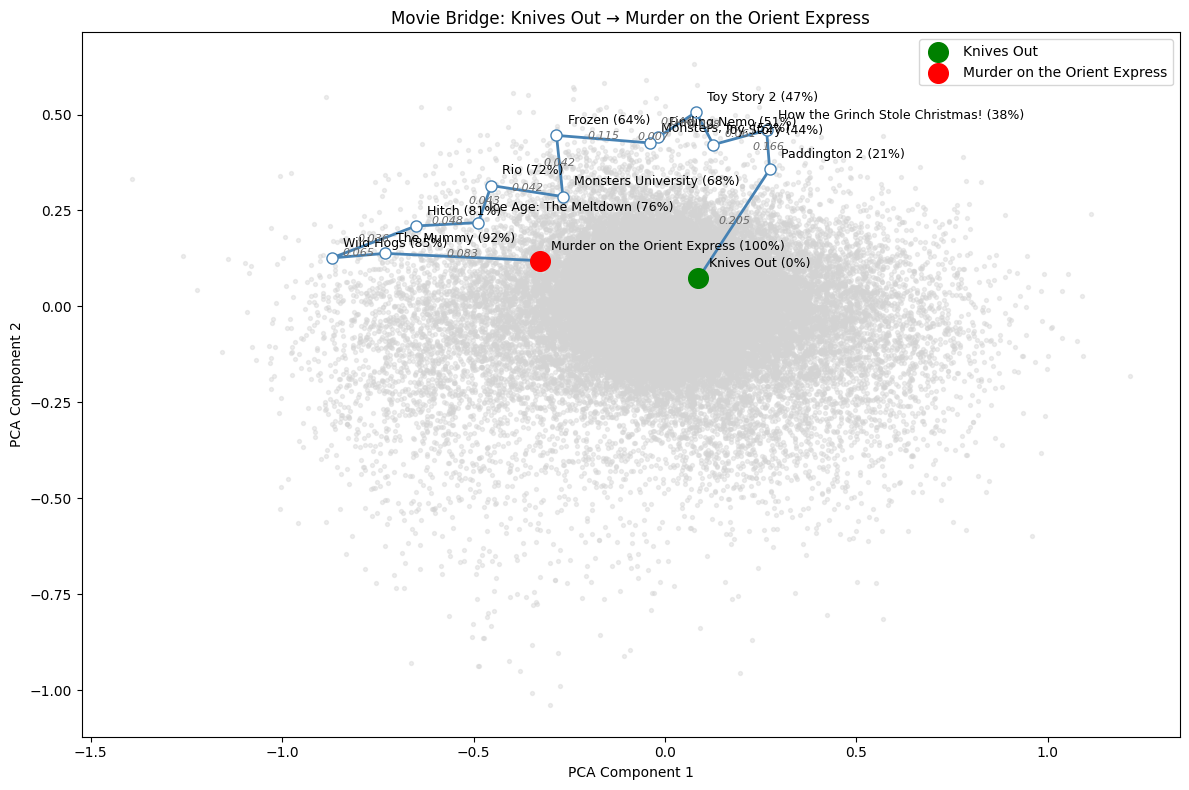

In [ ]:
plot_movie_bridge("Knives Out", "Murder on the Orient Express")

  - Baby Driver (2017) id=339403
  - Baby Driver Cartoon - Bellbottoms () id=910587
  - Whiplash (2014) id=244786
  - Whiplash (2013) id=367412
  - Whiplash (1948) id=84365
  - Whiplash (1974) id=370300
  - Whiplash (1997) id=282723
Bridge from 'Baby Driver' to 'Whiplash':

    0.0%  Baby Driver
   43.4%  The Nice Guys
   80.7%  A Fistful of Dollars
   88.9%  For a Few Dollars More
  100.0%  Whiplash



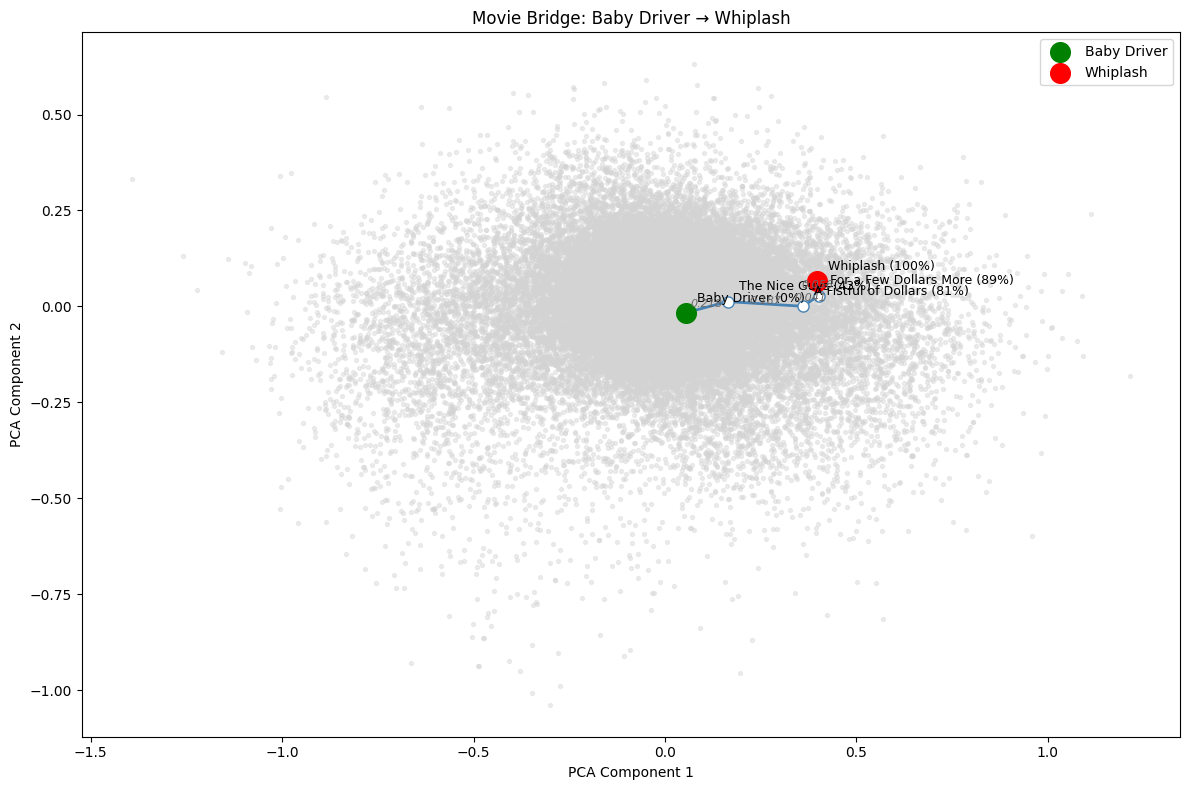

In [ ]:
plot_movie_bridge("Baby Driver", "Whiplash")

  - Inception (2010) id=27205
  - Bikini Inception (2015) id=542438
  - Inception (1980) id=1359046
  - Inception: The Cobol Job (2010) id=64956
  - WWA The Inception (2001) id=250845
  - Wedding Crashers (2005) id=9522
  - Undercover Wedding Crashers (2021) id=613098
Bridge from 'Inception' to 'Wedding Crashers':

    0.0%  Inception
   14.6%  V for Vendetta
   47.9%  The Boondock Saints
   64.0%  The Book of Eli
   69.3%  The Island
   73.0%  Mindhunters
   78.6%  The Longest Yard
   82.6%  Big Daddy
   92.4%  American Pie 2
  100.0%  Wedding Crashers



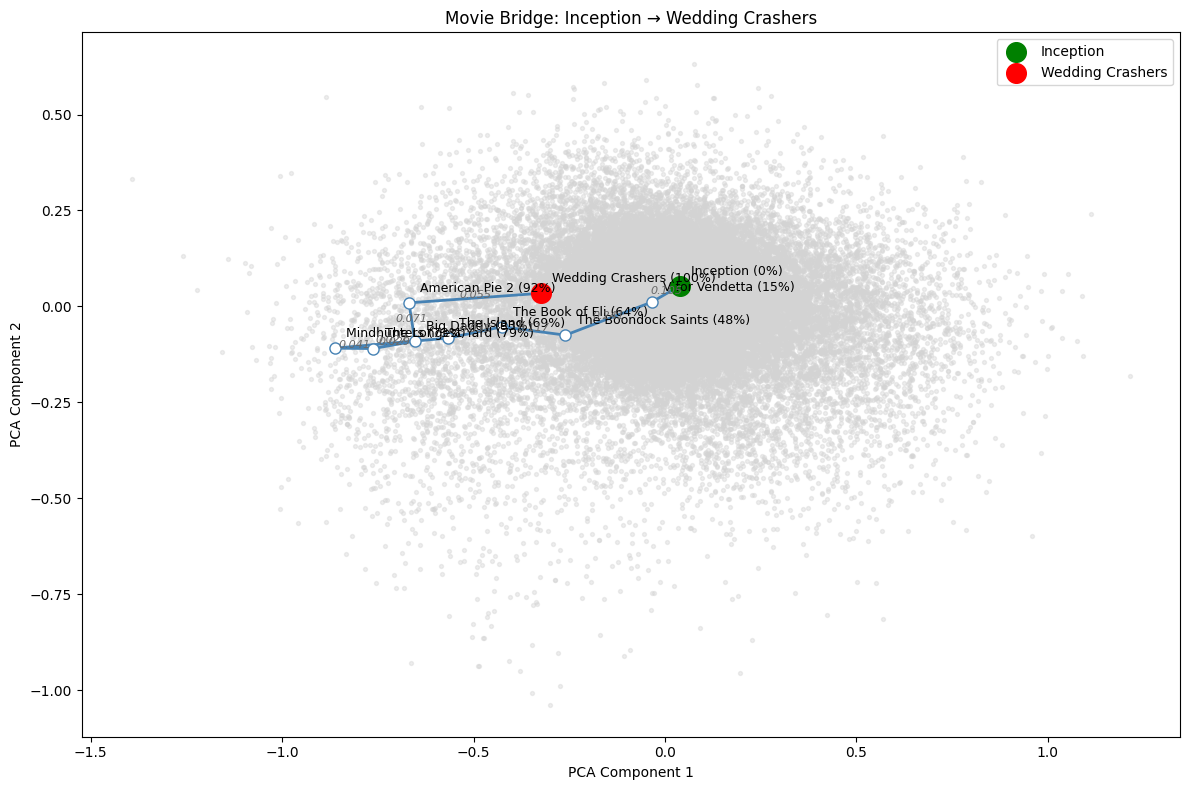

In [ ]:
plot_movie_bridge("Inception", "Wedding Crashers")

# **MAKING WEBSITE!**

One issue is that we're getting some results that aren't feature films. Fix this by cutting out all items under 70 mins. Also, cut out any movies with the tag "stand-up comedy"

In [ ]:
# Pull runtime/keywords in the same order as combined_matrix_filtered's rows
row_indices = [id_to_row[raw_id] for raw_id in filtered_raw_ids]
runtime_vals = movies_meta_df.loc[row_indices, 'runtime'].values
keywords_vals = movies_meta_df.loc[row_indices, 'keywords'].values

has_standup = np.array([
    'stand-upcomedy' in kw if isinstance(kw, list) else False
    for kw in keywords_vals
])

keep_mask = (runtime_vals >= 70) & ~has_standup

combined_matrix_filtered_final = combined_matrix_filtered[keep_mask]

# The id<->index mappings must shrink to match, or every downstream lookup
# (the rec function, the export cell) will point at the wrong rows.
filtered_raw_ids_final = [rid for rid, keep in zip(filtered_raw_ids, keep_mask) if keep]
raw_to_filtered_idx_final = {raw_id: idx for idx, raw_id in enumerate(filtered_raw_ids_final)}
filtered_idx_to_raw_final = {idx: raw_id for idx, raw_id in enumerate(filtered_raw_ids_final)}

print(f"Kept {combined_matrix_filtered_final.shape[0]} / {len(filtered_raw_ids)} movies "
      f"after runtime/keyword filtering")

# Reassign onto the original names so weighted_avg_embedding_rec and your export
# cell keep working unchanged, without needing to know about the "_final" versions.
combined_matrix_filtered = combined_matrix_filtered_final
filtered_raw_ids = filtered_raw_ids_final
raw_to_filtered_idx = raw_to_filtered_idx_final
filtered_idx_to_raw = filtered_idx_to_raw_final

Kept 15815 / 16306 movies after runtime/keyword filtering


In [ ]:
import pickle

artifacts = {
    "qi": combined_matrix_filtered,
    "raw_to_inner": raw_to_filtered_idx,
    "inner_to_raw": filtered_idx_to_raw,
    "movies_df": movies_meta_df[["id", "title", "release_year"]].rename(columns={"id": "movieId"}),
}

with open("model_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("Saved model_artifacts.pkl")

Saved model_artifacts.pkl


# **Wrap-Up**
If you want to try the blender yourself, the link is below.

WEBSITE LINK: https://movieblender.streamlit.app/

Overall, I'm happy with how it turned out. It's definitely not perfect, a lot of movies have a very strange and unexpected impact on the output, but a lot of them are also pretty dead-on. (I kind of like that it's not perfect; it makes it more surprising and interesting to use). I have used the blender myself to add a lot of movies to my watchlist, it's a great way to find movies you've never heard of quickly.

**Project Summary**:
- First notebook:
  - First foray into recommender systems.
  - Learned about dataset and how to create embeddings using latent-factor models.
  - Created a content-based, collaborative filtering, and combined recommender, that gives a rec list based on an input movie.
- This notebook:
  - Used TMDB API to get updated info for movies.
  - Used extended MovieLens ratings data to get more movies than last time.
  - Used vector embeddings to blend movie recs using content-based vectors, embeddings from latent factor model, and a combined version (final export).

In the future I'd like to be able to use an active rating database so that I can use all current movies; it's unfortunate that the best model I found is the one that relies on the limited dataset.
